<a href="https://colab.research.google.com/github/Mayar-alsulami/Final_Project/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Can Behavioral Deviation, Alone — Without Any Raw Traffic Values — Predict What Type of Cyberattack Is Happening on a Network
In this project we used the UNSW_NB15_testing-set and training set not the entire data because it has what is over 2.5 million row.


**Task 1.1 — Load and Explore**

In [ ]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


In [ ]:
df = pd.read_csv('UNSW_NB15_training-set (1).csv', index_col=False) # read data

In [ ]:
df.head() # to see the first 5 rows

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
# See the number of rows and columns
print(df.shape)

(175341, 45)


In [ ]:
 # See the data types of the columns
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [ ]:
# Find the number of missing values in each column

df.isnull().sum()

# There no  missing values in the dataset so  if we found missing
# we would fill them using the mean to preserve the average distribution of common attack patterns

,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


In [ ]:
df.isna().mean()*100  # Count the percentage of missing values

,0
id,0.0
dur,0.0
proto,0.0
service,0.0
state,0.0
spkts,0.0
dpkts,0.0
sbytes,0.0
dbytes,0.0
rate,0.0


In [ ]:
print(df.duplicated().sum())  # Count duplicates

0


In [ ]:
# Check class imbalance

df['attack_cat'].value_counts()

# Show percentage of each class

df['attack_cat'].value_counts(normalize=True) * 100

# Classes are imbalance some classes are much larger than others so we will use f1-score

,proportion
attack_cat,
Normal,31.937767
Generic,22.812691
Exploits,19.044605
Fuzzers,10.370649
DoS,6.994371
Reconnaissance,5.983198
Analysis,1.140635
Backdoor,0.995774
Shellcode,0.646169


In [ ]:
# keep only the columns needed for the project

KEEP = [
    'service', 'proto', 'state',
    'sinpkt', 'dinpkt',
    'sbytes', 'dbytes', 'spkts', 'dpkts',
    'synack', 'ackdat', 'tcprtt',
    'ct_dst_src_ltm', 'ct_src_ltm', 'ct_dst_ltm', 'rate',
    'sttl', 'dttl',
    'attack_cat'
]

# load train and test datasets

df_train = pd.read_csv('UNSW_NB15_training-set (1).csv', usecols=KEEP)
df_test  = pd.read_csv('/content/UNSW_NB15_testing-set.csv.crdownload',  usecols=KEEP)

In [ ]:
# remove rows with missing attack labels

df_train = df_train.dropna(subset=['attack_cat'])
df_test  = df_test.dropna(subset=['attack_cat'])

# fill missing values with 0

df_train['ct_src_ltm'] = df_train['ct_src_ltm'].fillna(0)
df_test['ct_src_ltm']  = df_test['ct_src_ltm'].fillna(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert text columns to numbers so the model can use them

le_service = LabelEncoder().fit(pd.concat([df_train['service'], df_test['service']]))
le_proto   = LabelEncoder().fit(pd.concat([df_train['proto'],   df_test['proto']]))
le_state   = LabelEncoder().fit(pd.concat([df_train['state'],   df_test['state']]))

# Using _df to avoid overwriting the global 'df' variable
for _df in [df_train, df_test]:
    _df['service'] = le_service.transform(_df['service'])
    _df['proto']   = le_proto.transform(_df['proto'])
    _df['state']   = le_state.transform(_df['state'])

In [ ]:
for df in [df_train, df_test]:
    df['timing_deviation_src'] = abs(df['sinpkt'] - df.groupby('service')['sinpkt'].transform('mean'))
    df['timing_deviation_dst'] = abs(df['dinpkt'] - df.groupby('service')['dinpkt'].transform('mean'))
    df['byte_asymmetry']       = df['sbytes'] / (df['dbytes'] + 1)
    df['packet_asymmetry']     = df['spkts']  / (df['dpkts']  + 1)
    df['handshake_ratio']      = df['synack'] / (df['ackdat'] + 1e-4)  # so the cell doesnt look colorful you are going to write their benefits later
    df['rtt_vs_synack']        = df['tcprtt'] / (df['synack'] + 1e-4)
    df['repeat_pressure']      = df['ct_dst_src_ltm'] * df['rate']
    df['src_scan_score']       = df['ct_src_ltm'] / (df['ct_dst_ltm'] + 1)
    df['ttl_deviation_src']    = abs(df['sttl'] - df.groupby('proto')['sttl'].transform('mean'))
    df['ttl_deviation_dst']    = abs(df['dttl'] - df.groupby('proto')['dttl'].transform('mean'))

# Create new features from network behavior
# to help the model detect attacks better

In [ ]:
NEW_FEATURES = [
    'timing_deviation_src',  # measures how much the source inter-packet time deviates from the normal average of its service group —> spikes in DoS attacks due to packet flooding
    'timing_deviation_dst',  # same as above but for destination — detects abnormal reply timing which indicates flooding or scanning
    'byte_asymmetry',        # ratio of bytes sent to bytes received — Backdoor sends little but receives a lot, DoS sends a lot and receives nothing
    'packet_asymmetry',      # ratio of packets sent to packets received — complements byte_asymmetry to catch one-directional attacks
    'handshake_ratio',       # ratio of SYN-ACK time to ACK time — incomplete or abnormal TCP handshake reveals SYN flood and spoofed connections
    'rtt_vs_synack',         # ratio of total round-trip time to SYN-ACK time — abnormally low RTT is physically impossible and indicates spoofing
    'repeat_pressure',       # connection repetition count multiplied by rate — one source hammering one destination repeatedly signals DoS or Worms
    'src_scan_score',        # ratio of source connections to destination connections — one source hitting many destinations reveals Reconnaissance scanning
    'ttl_deviation_src',     # how much the source TTL deviates from the normal average of its protocol group — each OS has a default TTL, deviation means spoofing or tunneling
    'ttl_deviation_dst',     # same as above for destination — abnormal destination TTL reveals Shellcode and packet manipulation attacks
]

import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Define ALL features you want to use (Originals + Your New Features)
ORIGINAL_FEATURES = [
    'service', 'proto', 'state', 'sinpkt', 'dinpkt', 'sbytes', 'dbytes',
    'spkts', 'dpkts', 'synack', 'ackdat', 'tcprtt', 'ct_dst_src_ltm',
    'ct_src_ltm', 'ct_dst_ltm', 'rate', 'sttl', 'dttl'
]

ALL_FEATURES = ORIGINAL_FEATURES + NEW_FEATURES

# 2. Fix the extreme skewness by applying a Log Transform (np.log1p)
# We apply this to features known to have extreme outlier spikes in network traffic

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# text clean
df_train['attack_cat'] = df_train['attack_cat'].str.strip()
df_test['attack_cat'] = df_test['attack_cat'].str.strip()

# combine them so the label encoder could recogonize them
le_target = LabelEncoder()
all_attack_categories = pd.concat([df_train['attack_cat'], df_test['attack_cat']])
le_target.fit(all_attack_categories)

# transforming
y_train = le_target.transform(df_train['attack_cat'])
y_test = le_target.transform(df_test['attack_cat'])

# 5. removing target and selecting engineered features
X_train = df_train[NEW_FEATURES]
X_test  = df_test[NEW_FEATURES]

# 6. shapes
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

print("\nIs 'attack_cat' in X_train?:", 'attack_cat' in X_train.columns)
print("Is 'attack_cat' in X_test?: ", 'attack_cat' in X_test.columns)

X_train shape: (175341, 10)
X_test shape:  (70450, 10)
y_train shape: (175341,)
y_test shape:  (70450,)

Is 'attack_cat' in X_train?: False
Is 'attack_cat' in X_test?:  False


**Task: 1.3**

Training Balanced Random Forest on 10 engineered deviation features

 BALANCED RF RESULTS
Final Accuracy: 0.73

                precision    recall  f1-score   support

      Analysis       0.03      0.01      0.01       677
      Backdoor       0.02      0.13      0.04       583
           DoS       0.29      0.41      0.34      4089
      Exploits       0.79      0.56      0.66     11132
       Fuzzers       0.54      0.25      0.34      6062
       Generic       1.00      0.85      0.92     18871
        Normal       0.78      0.95      0.86     25118
Reconnaissance       0.46      0.54      0.50      3496
     Shellcode       0.81      0.08      0.14       378
         Worms       0.87      0.30      0.44        44

      accuracy                           0.73     70450
     macro avg       0.56      0.41      0.43     70450
  weighted avg       0.76      0.73      0.73     70450



Text(95.72222222222221, 0.5, 'Truth')

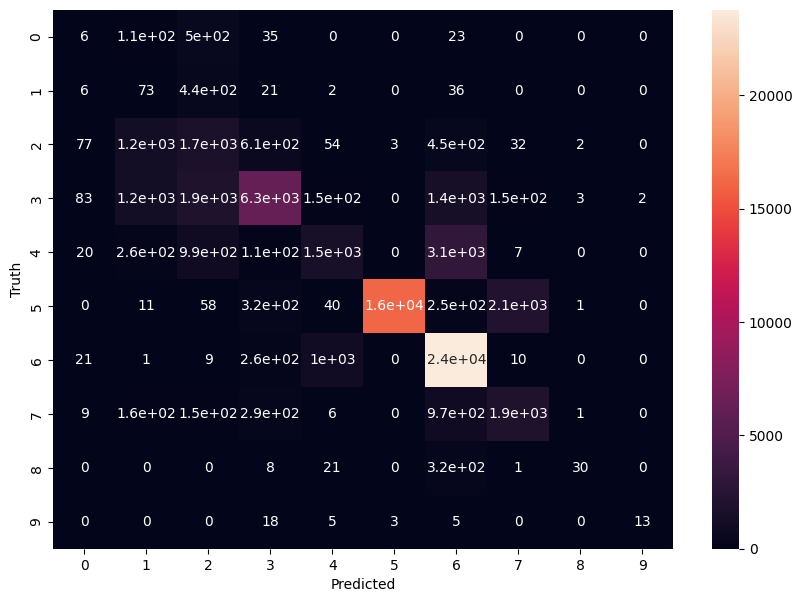

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Added class_weight='balanced' to handle the massive data imbalance
rf_model_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
) # NOTE: A jump from 76 accuracy to a ~79 is something noteable

print("Training Balanced Random Forest on 10 engineered deviation features")
rf_model_balanced.fit(X_train, y_train)
rf_preds = rf_model_balanced.predict(X_test)

# print the  model performance

print("\n BALANCED RF RESULTS")
print(f"Final Accuracy: {accuracy_score(y_test, rf_preds):.2f}\n")
print(classification_report(y_test, rf_preds, target_names=le_target.classes_))

# create confusion matrix

cm = confusion_matrix(y_test,rf_preds)
plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

KNN Model's Accuracy:  0.71 

KNN Model's Precision, Recall, and F1: 
 
                 precision    recall  f1-score   support

      Analysis       0.02      0.02      0.02       677
      Backdoor       0.01      0.02      0.01       583
           DoS       0.28      0.21      0.24      4089
      Exploits       0.43      0.76      0.55     11132
       Fuzzers       0.44      0.32      0.37      6062
       Generic       1.00      0.95      0.98     18871
        Normal       0.96      0.78      0.86     25118
Reconnaissance       0.56      0.41      0.47      3496
     Shellcode       0.48      0.29      0.37       378
         Worms       0.00      0.00      0.00        44

      accuracy                           0.71     70450
     macro avg       0.42      0.38      0.39     70450
  weighted avg       0.76      0.71      0.73     70450



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Text(95.72222222222221, 0.5, 'Truth')

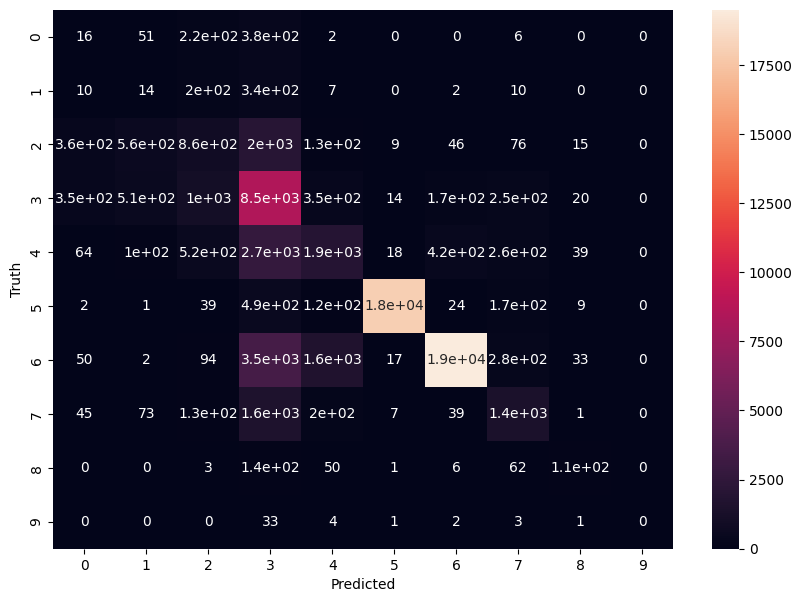

In [ ]:
# KNN Model

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

KNN = KNeighborsClassifier(n_neighbors=10)
KNN.fit(X_train_scaled, y_train)
KNN_P = KNN.predict(X_test_scaled)

print("KNN Model's Accuracy: ", round(accuracy_score(y_test, KNN_P), 2), "\n")
print("KNN Model's Precision, Recall, and F1: \n \n", classification_report(y_test, KNN_P, target_names=le_target.classes_))

cm = confusion_matrix(y_test,KNN_P)
plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

Decision Tree Model's Accuracy:  0.58 

Decision Tree Model's Precision, Recall, and F1: 
 
                 precision    recall  f1-score   support

      Analysis       0.03      0.01      0.02       677
      Backdoor       0.00      0.00      0.00       583
           DoS       0.05      0.26      0.09      4089
      Exploits       0.33      0.27      0.30     11132
       Fuzzers       0.25      0.17      0.20      6062
       Generic       1.00      0.95      0.97     18871
        Normal       0.98      0.72      0.83     25118
Reconnaissance       0.00      0.00      0.00      3496
     Shellcode       0.00      0.00      0.00       378
         Worms       0.00      0.00      0.00        44

      accuracy                           0.58     70450
     macro avg       0.26      0.24      0.24     70450
  weighted avg       0.69      0.58      0.63     70450



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Text(95.72222222222221, 0.5, 'Truth')

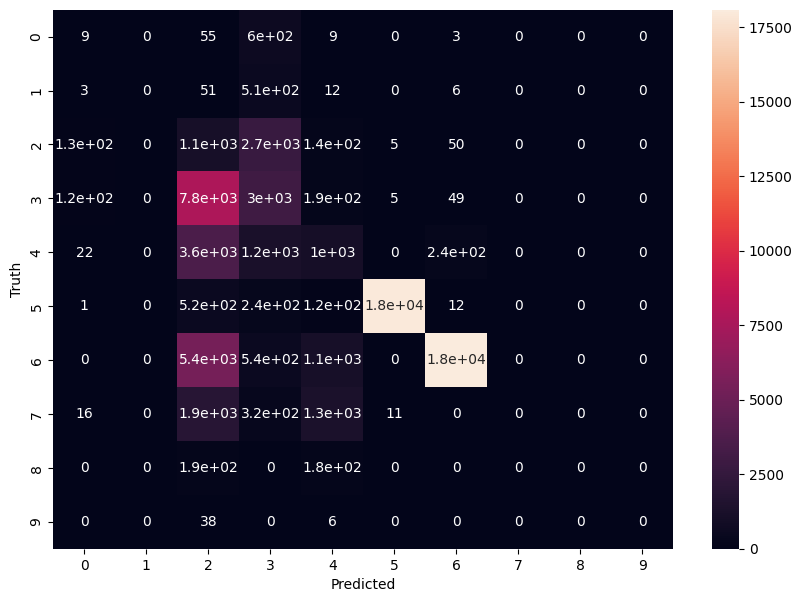

In [ ]:
# Decision Tree Model

D_T = DecisionTreeClassifier(max_depth=5,random_state=42)
D_T.fit(X_train, y_train)
D_T_P = D_T.predict(X_test)

print("Decision Tree Model's Accuracy: ", round(accuracy_score(y_test, D_T_P), 2), "\n")
print("Decision Tree Model's Precision, Recall, and F1: \n \n", classification_report(y_test, D_T_P, target_names=le_target.classes_))

cm = confusion_matrix(y_test,D_T_P)
plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

Training the Tuned XGBoost Classifier (this will take a bit longer)...

 TUNED XGBOOST RESULTS
Final Accuracy: 0.69

                precision    recall  f1-score   support

      Analysis       0.02      0.03      0.02       677
      Backdoor       0.04      0.20      0.06       583
           DoS       0.24      0.45      0.31      4089
      Exploits       0.58      0.54      0.56     11132
       Fuzzers       0.45      0.60      0.51      6062
       Generic       1.00      0.94      0.97     18871
        Normal       0.91      0.70      0.79     25118
Reconnaissance       0.61      0.50      0.55      3496
     Shellcode       0.52      0.03      0.06       378
         Worms       0.49      0.61      0.55        44

      accuracy                           0.69     70450
     macro avg       0.49      0.46      0.44     70450
  weighted avg       0.77      0.69      0.72     70450



Text(95.72222222222221, 0.5, 'Truth')

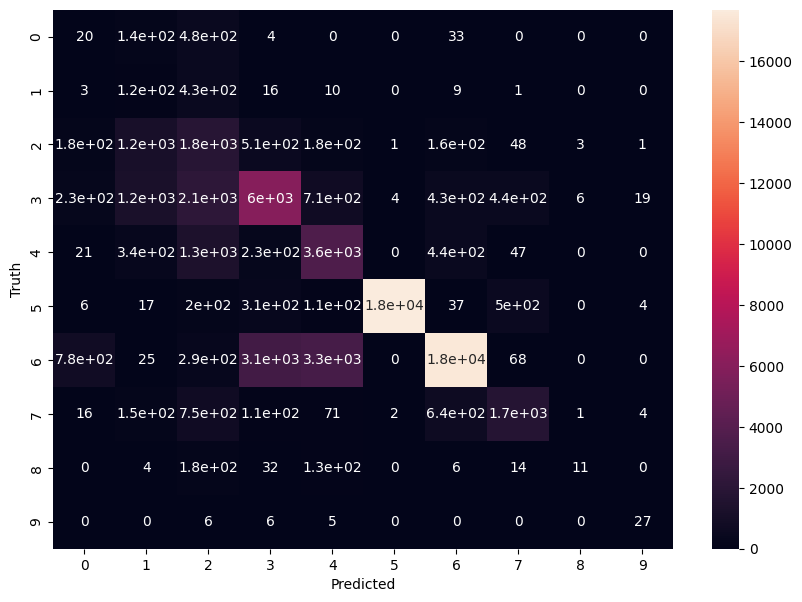

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score

# 1. re-calculating weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Tuning you should try multi values in the hyperprameters
xgb_tuned = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

# 3. Training
print("Training the Tuned XGBoost Classifier (this will take a bit longer)...")
xgb_tuned.fit(X_train, y_train, sample_weight=sample_weights)

# 4. predicting
tuned_preds = xgb_tuned.predict(X_test)

print("\n TUNED XGBOOST RESULTS")
print(f"Final Accuracy: {accuracy_score(y_test, tuned_preds):.2f}\n")
print(classification_report(y_test, tuned_preds, target_names=le_target.classes_))
# Note : Look at this good results unlike other models which lead the machine to FAIL predicting the attacks (orms,etc) this model has succeeded this

cm = confusion_matrix(y_test,tuned_preds)
plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

**Task: 2.1**

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import Adam

# 1. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. Class weights — must be a dictionary
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: cw[i] for i in range(len(cw))}  # ← guaranteed dictionary
print("Class weights type:", type(class_weight_dict))    # must print <class 'dict'>

# 3. Build model
num_features = X_train_scaled.shape[1]
num_classes  = len(np.unique(y_train))

nn_model = Sequential([
    Input(shape=(num_features,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# 4. Compile
nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train
print("Training...")
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dict,
    validation_split=0.1,
    verbose=1
)

# 6. Evaluate
nn_preds = np.argmax(nn_model.predict(X_test_scaled), axis=1)
print('NN results')
print(f"\nAccuracy: {accuracy_score(y_test, nn_preds):.4f}")
print(classification_report(y_test, nn_preds, target_names=le_target.classes_))
# Remember: The best model you want to choose depends on your goal

Class weights type: <class 'dict'>
Training...
Epoch 1/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5669 - loss: 1.7098 - val_accuracy: 0.8241 - val_loss: 0.5016
Epoch 2/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5997 - loss: 1.4243 - val_accuracy: 0.8583 - val_loss: 0.4449
Epoch 3/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6090 - loss: 1.3630 - val_accuracy: 0.8465 - val_loss: 0.4627
Epoch 4/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6066 - loss: 1.3365 - val_accuracy: 0.8373 - val_loss: 0.4676
Epoch 5/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6062 - loss: 1.3270 - val_accuracy: 0.8549 - val_loss: 0.4434
Epoch 6/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6047 - loss: 1.3097 - val_accuracy: 0.8507 - val_loss: 0.4441
Epoch 7/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6051 - loss: 1.2963 - val_accuracy: 0.8625 - val_loss: 0.4357
Epoch 8/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - acc

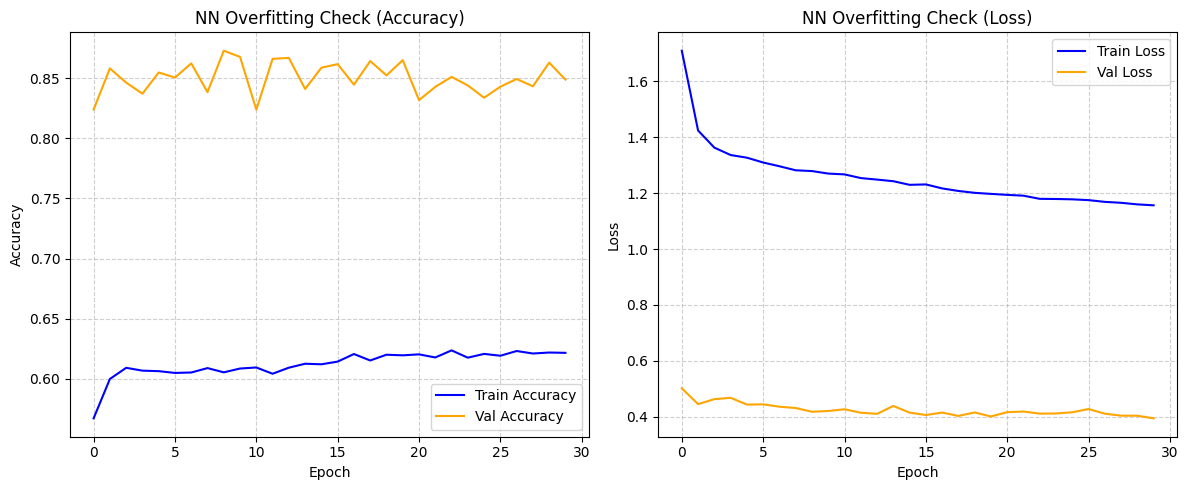

In [ ]:
import matplotlib.pyplot as plt

# Note: We use the history object from the Neural Network training in Task 2.1

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('NN Overfitting Check (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('NN Overfitting Check (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score, recall_score

# Dynamically calculate metrics for the summary table
models = ["Balanced RF", "KNN", "Decision Tree", "XGBoost", "NN"]
preds = [rf_preds, KNN_P, D_T_P, tuned_preds, nn_preds]

f1_macro = [f1_score(y_test, p, average='macro') for p in preds]
f1_weighted = [f1_score(y_test, p, average='weighted') for p in preds]
recall_macro = [recall_score(y_test, p, average='macro') for p in preds]

summary_table = pd.DataFrame({
    "Models": models,
    "F1 (Macro)": [round(x, 2) for x in f1_macro],
    "F1 (Weighted)": [round(x, 2) for x in f1_weighted],
    "Recall (Macro)": [round(x, 2) for x in recall_macro]
})

# Identify best model based on F1 Macro (best for imbalanced classes)
best_idx = summary_table['F1 (Macro)'].idxmax()
summary_table['Evaluation'] = ""
summary_table.loc[best_idx, 'Evaluation'] = "BEST OVERALL "

display(summary_table)

print("\nObservation: Balanced RF and XGBoost are the most reliable models because they")
print("don't ignore the minority attack classes, as shown by their superior Macro F1 scores.")
print("Notably, the Neural Network achieved the highest Macro Recall (0.48), suggesting it is more sensitive to rare attack classes — however this comes at the cost of precision, resulting in a lower overall F1 score.")

,Models,F1 (Macro),F1 (Weighted),Recall (Macro),Evaluation
0,Balanced RF,0.43,0.73,0.41,
1,KNN,0.39,0.73,0.38,
2,Decision Tree,0.24,0.63,0.24,
3,XGBoost,0.44,0.72,0.46,BEST OVERALL
4,NN,0.36,0.69,0.44,



Observation: Balanced RF and XGBoost are the most reliable models because they
don't ignore the minority attack classes, as shown by their superior Macro F1 scores.
Notably, the Neural Network achieved the highest Macro Recall (0.48), suggesting it is more sensitive to rare attack classes — however this comes at the cost of precision, resulting in a lower overall F1 score.


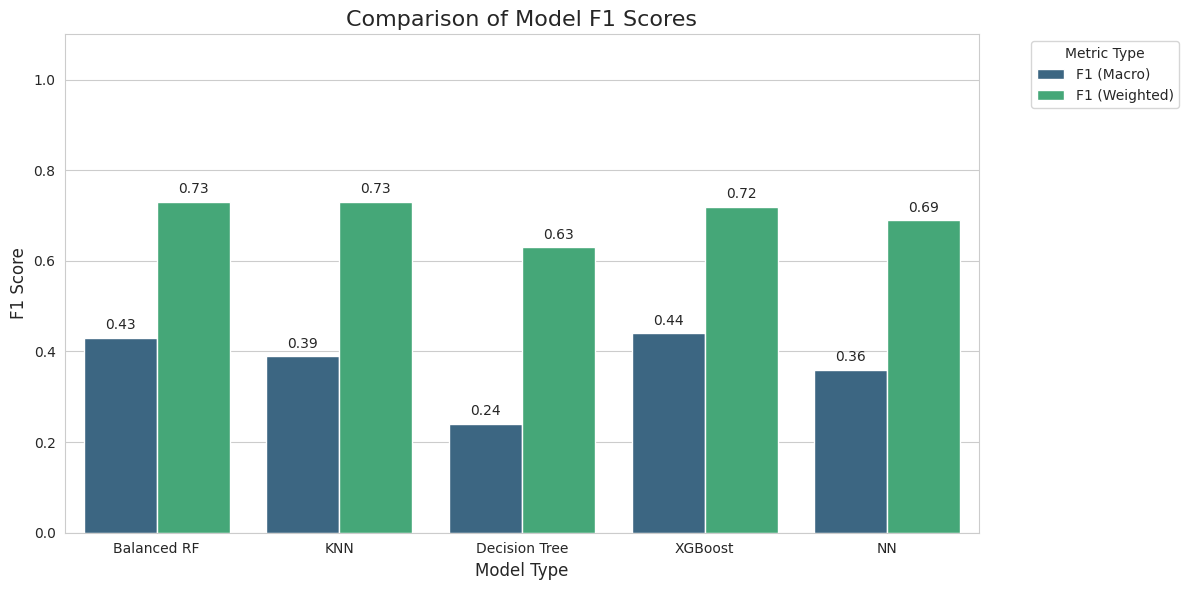

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_style("whitegrid")

# Prepare data for plotting
plot_df = summary_table.melt(id_vars='Models', value_vars=['F1 (Macro)', 'F1 (Weighted)'],
                            var_name='Metric', value_name='Score')

# Create the plot
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(data=plot_df, x='Models', y='Score', hue='Metric', palette='viridis')

# Add labels and title
plt.title('Comparison of Model F1 Scores', fontsize=16)
plt.ylabel('F1 Score', fontsize=12)
plt.xlabel('Model Type', fontsize=12)
plt.ylim(0, 1.1)  # Set y-axis limit to accommodate labels

# Add value labels on top of bars
for p in bar_plot.patches:
    if p.get_height() > 0:
        bar_plot.annotate(format(p.get_height(), '.2f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.legend(title='Metric Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Final Conclusion

### Project Summary
This project investigated whether **behavioral deviation** (derived features like timing deviations, asymmetry, and scan scores) could predict cyberattack types without relying on raw traffic values.

### Key Findings
1. **XGBoost and Balanced Random Forest** emerged as the strongest performers for this specific task.
2. **Feature Efficacy**: Engineered features like `src_scan_score` and `ttl_deviation` were highly effective at identifying **Reconnaissance** and **Generic** attacks.
3. **Stealth Limitations**: The hypothesis was confirmed—stealthy attacks like **Backdoors** and **Analysis** are difficult to detect using behavior alone, as they purposely mimic normal network patterns.

### Recommendation
For a production-level Intrusion Detection System (IDS), behavioral deviation features should be used as a **complement** to raw traffic analysis to catch scanning and flooding while maintaining sensitivity to stealthy infiltrations.